# Cell Death Analysis — Debug Notebook

Standalone analysis from **linked labels** (skips segmentation & tracking).  
Imports analysis functions from the split modules: `measurement.py`, `segmentation.py`, `fate_assignment.py`, `colours.py`, `plotting.py`.

## Inputs needed
- Original multi-channel TIFF
- `linked_labels_trackmate.tiff` (from tracking stage)
- `trackmate_tracks.csv` (optional, for trajectory/timeline plots)

In [ ]:
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import napari

from measurement import measure_all_cells_in_frame, assign_positive_objects_to_cells, compute_cell_positivity
from segmentation import segment_fluorescence
from fate_assignment import (
    assign_persistent_fates, assign_snapshot_fates,
    compute_persistent_percentages, compute_snapshot_percentages,
    filter_by_frame_presence, filter_persistent_by_frame_presence,
)
from colours import COLOUR_KEYWORDS, assign_colours, build_category_colormap
from plotting import (
    plot_persistent_percentages, plot_snapshot_percentages,
    plot_snapshot_trajectories, plot_snapshot_cell_timelines,
)

%matplotlib inline

In [ ]:
# All analysis functions are now imported from the split modules:
#   measurement.py, segmentation.py, fate_assignment.py, colours.py, plotting.py
print("Functions imported from split modules — ready to use.")

## 1. Configure paths & channels

In [26]:
# --- EDIT THESE ---
tiff_path = Path(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\Marcus_Kerrie-mid_t-small1.tif")
work_dir = Path(r"C:\Users\taylorhearn\Dropbox\Shared_With_Me\kerrie_outputs\Marcus_Kerrie-mid_t-small1")  # folder with linked_labels_trackmate.tiff

# Channel indices in the original TIFF (0-based)
brightfield_channel = 0
fluorophore_channels = [0,1]          # indices of fluorescence channels
fluorophore_names    = ["Red", "Green"]  # matching names

# Thresholding
threshold_method = "otsu"  # or dict: {"Annexin V": "mean", "PI": "otsu"}
blur_sigma = 1.0

# Frame-presence cutoffs for filtered plots (%)
cutoff_pcts = [30, 40, 50, 60]

## 2. Load data

In [27]:
# Load the original image and extract fluorescence channels
raw = tifffile.imread(str(tiff_path))
print(f"Raw image shape: {raw.shape}")

# Expected shape: (frames, channels, H, W) or (frames, H, W) for single-channel
# Adjust indexing below if your axis order differs
fluor_images = {}
for channel_index, channel_name in zip(fluorophore_channels, fluorophore_names):
    fluor_images[channel_name] = raw[:, channel_index, :, :]
    print(f"  {channel_name} (ch {channel_index}): {fluor_images[channel_name].shape}")

# Load linked labels
linked_path = work_dir / "linked_labels_trackmate.tiff"
linked_labels = tifffile.imread(str(linked_path)).astype(np.uint32)
print(f"Linked labels shape: {linked_labels.shape}")
print(f"  Unique cell IDs: {len(np.unique(linked_labels)) - 1}")

n_frames = linked_labels.shape[0]
print(f"  Frames: {n_frames}")

# Load tracks CSV (optional — needed for trajectory & timeline plots)
tracks_csv = work_dir / "trackmate_tracks.csv"
if tracks_csv.exists():
    tracks_df = pd.read_csv(tracks_csv)
    print(f"Tracks CSV loaded: {len(tracks_df)} rows, {tracks_df['track_id'].nunique()} tracks")
else:
    tracks_df = pd.DataFrame(columns=["track_id", "t", "y", "x", "quality"])
    print("No tracks CSV found — trajectory/timeline plots will be skipped")

Raw image shape: (7, 3, 2200, 2688)
  Red (ch 0): (7, 2200, 2688)
  Green (ch 1): (7, 2200, 2688)
Linked labels shape: (7, 2200, 2688)
  Unique cell IDs: 1210
  Frames: 7
Tracks CSV loaded: 7334 rows, 1212 tracks


## 3. Fluorescence segmentation (thresholding)

In [28]:
fluorescence_output = segment_fluorescence(fluor_images, blur_sigma=blur_sigma, threshold_method=threshold_method)

# Boolean masks (for visual checks)
pos_masks = {fluorophore_name: fluorescence_output[fluorophore_name]["positive"] for fluorophore_name in fluorophore_names}
# Labeled positive objects (for COM-based analysis)
pos_label_imgs = {fluorophore_name: fluorescence_output[fluorophore_name]["positive_labels"] for fluorophore_name in fluorophore_names}

# Compute COM-based cell positivity ONCE — shared by Napari QC and all analysis
frame_cell_pos, positive_cell_labels = compute_cell_positivity(
    linked_labels, pos_label_imgs, fluorophore_names
)

for fluorophore_name in fluorophore_names:
    thresholds = fluorescence_output[fluorophore_name]["thresholds_per_frame"]
    num_positive_pixels = np.count_nonzero(pos_masks[fluorophore_name])
    total_pixels = pos_masks[fluorophore_name].size
    num_positive_cells = len(set().union(*(frame_cell_pos[fluorophore_name][frame].keys() for frame in range(n_frames))))
    print(f"{fluorophore_name}: threshold min={thresholds.min():.2f} mean={thresholds.mean():.2f} max={thresholds.max():.2f}, positive pixels={num_positive_pixels} ({100*num_positive_pixels/total_pixels:.1f}%), unique positive cells={num_positive_cells}")

Red: threshold min=897.81 mean=952.23 max=995.52, positive pixels=47926 (0.1%), unique positive cells=74
Green: threshold min=1832.26 mean=1983.68 max=2176.88, positive pixels=52510 (0.1%), unique positive cells=54


### Confirm Fluorescence-Positive Blobs Are Assigned to Their Corresponding Cell

In [ ]:
viewer = napari.Viewer()
viewer.add_labels(linked_labels, name="All cells")
for fluorophore_name in fluorophore_names:
    viewer.add_image(fluor_images[fluorophore_name], name=fluorophore_name, blending="additive")
    viewer.add_labels(positive_cell_labels[fluorophore_name].astype(np.int32),
        name=f"{fluorophore_name} positive cells", opacity=0.4)

---
## 4a. Persistent analysis

In [30]:
assignments_df, locked_labels, persistent_per_frame = assign_persistent_fates(linked_labels, frame_cell_pos)
assignments_df = assignments_df.sort_values("label_id").reset_index(drop=True)

print(f"Cells: {len(assignments_df)}")
print(f"Fate distribution:\n{assignments_df['fate'].value_counts().to_string()}")
assignments_df.head(10)

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_128580\1292275406.py:21: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axis = region.major_axis_length
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_128580\1292275406.py:22: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  minor_axis = region.minor_axis_length


Cells: 1210
Fate distribution:
fate
negative    1099
Red           70
Green         41


,label_id,mean_area,mean_roundness,first_Red_frame,Red_positive_area,first_Green_frame,Green_positive_area,first_positive_frame,fate
0,1,3195.333333,0.545266,NaN,0.0,NaN,0.0,NaN,negative
1,2,3559.833333,0.661253,NaN,0.0,NaN,0.0,NaN,negative
2,3,6284.857143,0.669162,NaN,0.0,NaN,0.0,NaN,negative
3,4,4191.166667,0.420583,NaN,0.0,NaN,0.0,NaN,negative
4,5,6374.166667,0.520600,NaN,0.0,NaN,0.0,NaN,negative
5,6,5295.500000,0.707475,NaN,0.0,NaN,0.0,NaN,negative
6,7,4242.714286,0.604512,NaN,0.0,NaN,0.0,NaN,negative
7,8,3482.833333,0.644664,NaN,0.0,NaN,0.0,NaN,negative
8,9,4171.714286,0.617374,NaN,0.0,NaN,0.0,NaN,negative
9,10,4584.000000,0.402042,NaN,0.0,NaN,0.0,NaN,negative


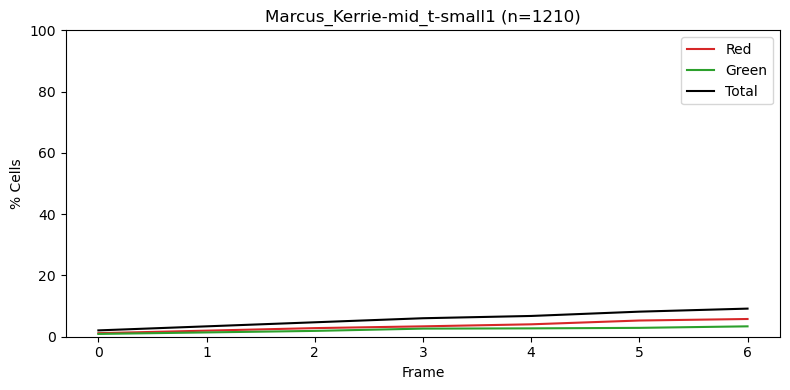

,frame,Red_pct,Green_pct,total_positive_pct
2,2,2.809917,1.900826,4.710744
3,3,3.388430,2.644628,6.033058
4,4,4.049587,2.727273,6.776860
5,5,5.289256,2.892562,8.181818
6,6,5.785124,3.388430,9.173554


In [31]:
# Percentage curves
summary_persistent = compute_persistent_percentages(assignments_df, n_frames, fluorophore_names)
fig, ax = plot_persistent_percentages(summary_persistent, fluorophore_names, title=f"{tiff_path.stem} (n={len(assignments_df)})")
plt.show()

summary_persistent.tail()

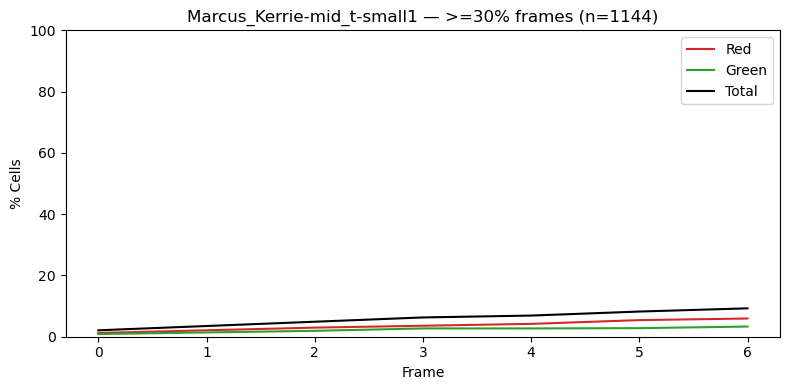

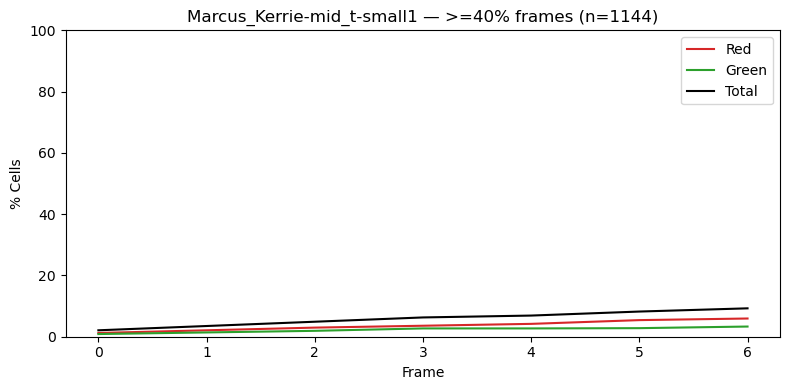

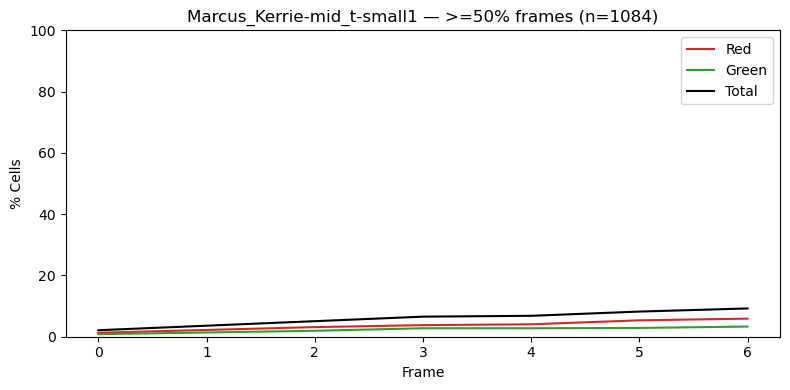

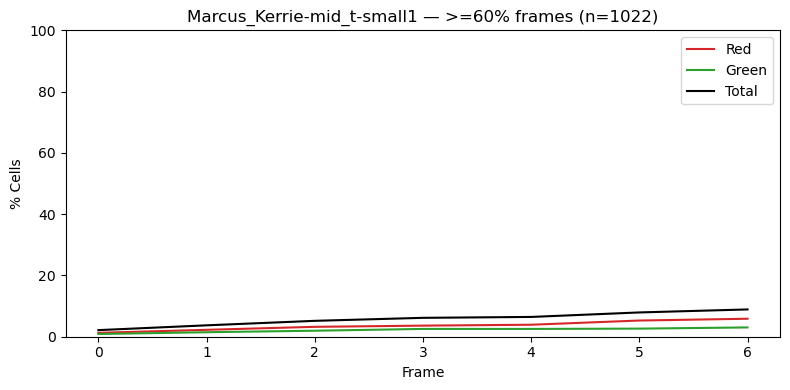

In [ ]:
# Filtered by frame presence
for cutoff in cutoff_pcts:
    filtered_assignments = filter_persistent_by_frame_presence(assignments_df, linked_labels, n_frames, cutoff)
    num_cells = len(filtered_assignments)
    if num_cells == 0:
        print(f"No cells at >= {cutoff}% frame presence, skipping")
        continue
    filtered_summary = compute_persistent_percentages(filtered_assignments, n_frames, fluorophore_names)
    fig, ax = plot_persistent_percentages(
        filtered_summary, fluorophore_names,
        title=f"{tiff_path.stem} — >={cutoff}% frames (n={num_cells})"
    )
    plt.show()

In [33]:
# Per-frame data
print(f"Per-frame rows: {len(persistent_per_frame)}")
persistent_per_frame.head(10)

Per-frame rows: 7139


,label_id,frame,area,roundness,Red_positive_area,Green_positive_area,fate
0,1,0,3278.0,0.459280,0.0,0.0,negative
1,1,1,2828.0,0.636943,0.0,0.0,negative
2,1,2,3245.0,0.559901,0.0,0.0,negative
3,1,3,2615.0,0.461666,0.0,0.0,negative
4,1,5,2856.0,0.659929,0.0,0.0,negative
5,1,6,4350.0,0.493877,0.0,0.0,negative
6,2,0,3046.0,0.590695,0.0,0.0,negative
7,2,1,3451.0,0.873645,0.0,0.0,negative
8,2,2,3192.0,0.465704,0.0,0.0,negative
9,2,3,4203.0,0.757392,0.0,0.0,negative


In [39]:
# Build cumulative persistent labels: at frame t, only show cells whose
# first positive frame for that fate is <= t
cumulative_persistent = {}
for fluorophore_name in fluorophore_names:
    fate_cells = assignments_df.loc[
        assignments_df["fate"] == fluorophore_name,
        ["label_id", f"first_{fluorophore_name}_frame"],
    ]
    output_labels = np.zeros_like(linked_labels)
    for row_index, row in fate_cells.iterrows():
        label_id = int(row["label_id"])
        first_positive_frame = int(row[f"first_{fluorophore_name}_frame"])
        for frame_index in range(first_positive_frame, n_frames):
            mask = linked_labels[frame_index] == label_id
            output_labels[frame_index][mask] = label_id
    cumulative_persistent[fluorophore_name] = output_labels

viewer = napari.Viewer()
viewer.add_labels(linked_labels, name="All cells")
for index, fluorophore_name in enumerate(fluorophore_names):
    viewer.add_image(fluor_images[fluorophore_name], name=fluorophore_name, blending="additive")
    viewer.add_labels(positive_cell_labels[fluorophore_name].astype(np.int32),
        name=f"{fluorophore_name} positive (this frame)", opacity=0.4)
    viewer.add_labels(cumulative_persistent[fluorophore_name].astype(np.int32),
        name=f"{fluorophore_name} persistent (cumulative)", opacity=0.5)
napari.run()

---
## 4b. Snapshot analysis

In [35]:
snapshot_df = assign_snapshot_fates(linked_labels, frame_cell_pos)
snapshot_df = snapshot_df.sort_values(["label_id", "frame"]).reset_index(drop=True)

print(f"Snapshot rows: {len(snapshot_df)}")
print(f"Categories: {sorted(snapshot_df['category'].unique())}")
print(f"\nCategory distribution:\n{snapshot_df['category'].value_counts().to_string()}")
snapshot_df.head(10)

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_128580\1292275406.py:21: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axis = region.major_axis_length
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_128580\1292275406.py:22: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  minor_axis = region.minor_axis_length


Snapshot rows: 7139
Categories: ['Green', 'Red', 'Red+Green', 'negative']

Category distribution:
category
negative     6891
Red           109
Green         102
Red+Green      37


,label_id,frame,area,roundness,Red,Green,Red_positive_area,Green_positive_area,category
0,1,0,3278.0,0.459280,False,False,0.0,0.0,negative
1,1,1,2828.0,0.636943,False,False,0.0,0.0,negative
2,1,2,3245.0,0.559901,False,False,0.0,0.0,negative
3,1,3,2615.0,0.461666,False,False,0.0,0.0,negative
4,1,5,2856.0,0.659929,False,False,0.0,0.0,negative
5,1,6,4350.0,0.493877,False,False,0.0,0.0,negative
6,2,0,3046.0,0.590695,False,False,0.0,0.0,negative
7,2,1,3451.0,0.873645,False,False,0.0,0.0,negative
8,2,2,3192.0,0.465704,False,False,0.0,0.0,negative
9,2,3,4203.0,0.757392,False,False,0.0,0.0,negative


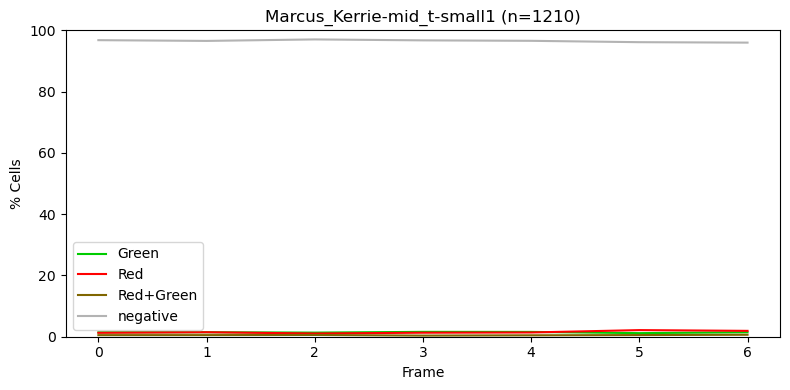

,frame,Green_pct,Red_pct,Red+Green_pct,negative_pct
2,2,1.339713,1.052632,0.574163,97.033493
3,3,1.590271,1.309635,0.374181,96.725912
4,4,1.572618,1.387604,0.462535,96.577243
5,5,1.169065,2.158273,0.539568,96.133094
6,6,1.458523,1.914312,0.638104,95.989061


In [36]:
# Percentage curves
summary_snapshot, categories = compute_snapshot_percentages(snapshot_df, n_frames)
fig, ax = plot_snapshot_percentages(summary_snapshot, categories, title=f"{tiff_path.stem} (n={snapshot_df['label_id'].nunique()})")
plt.show()

summary_snapshot.tail()

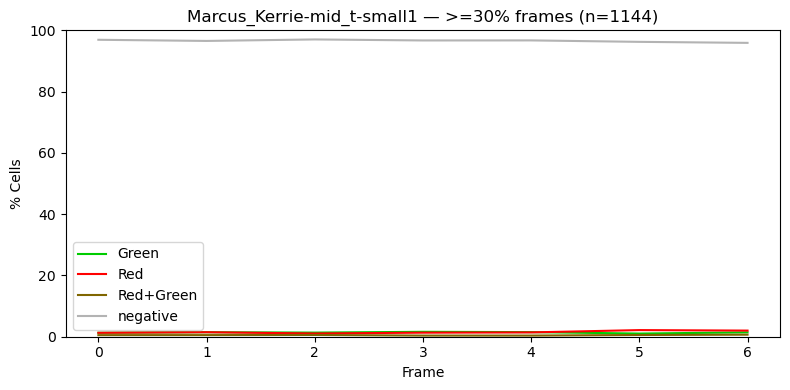

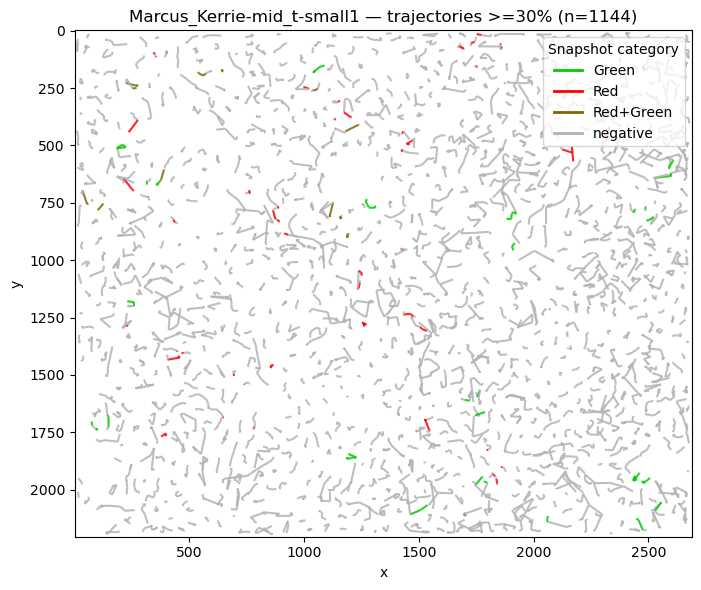

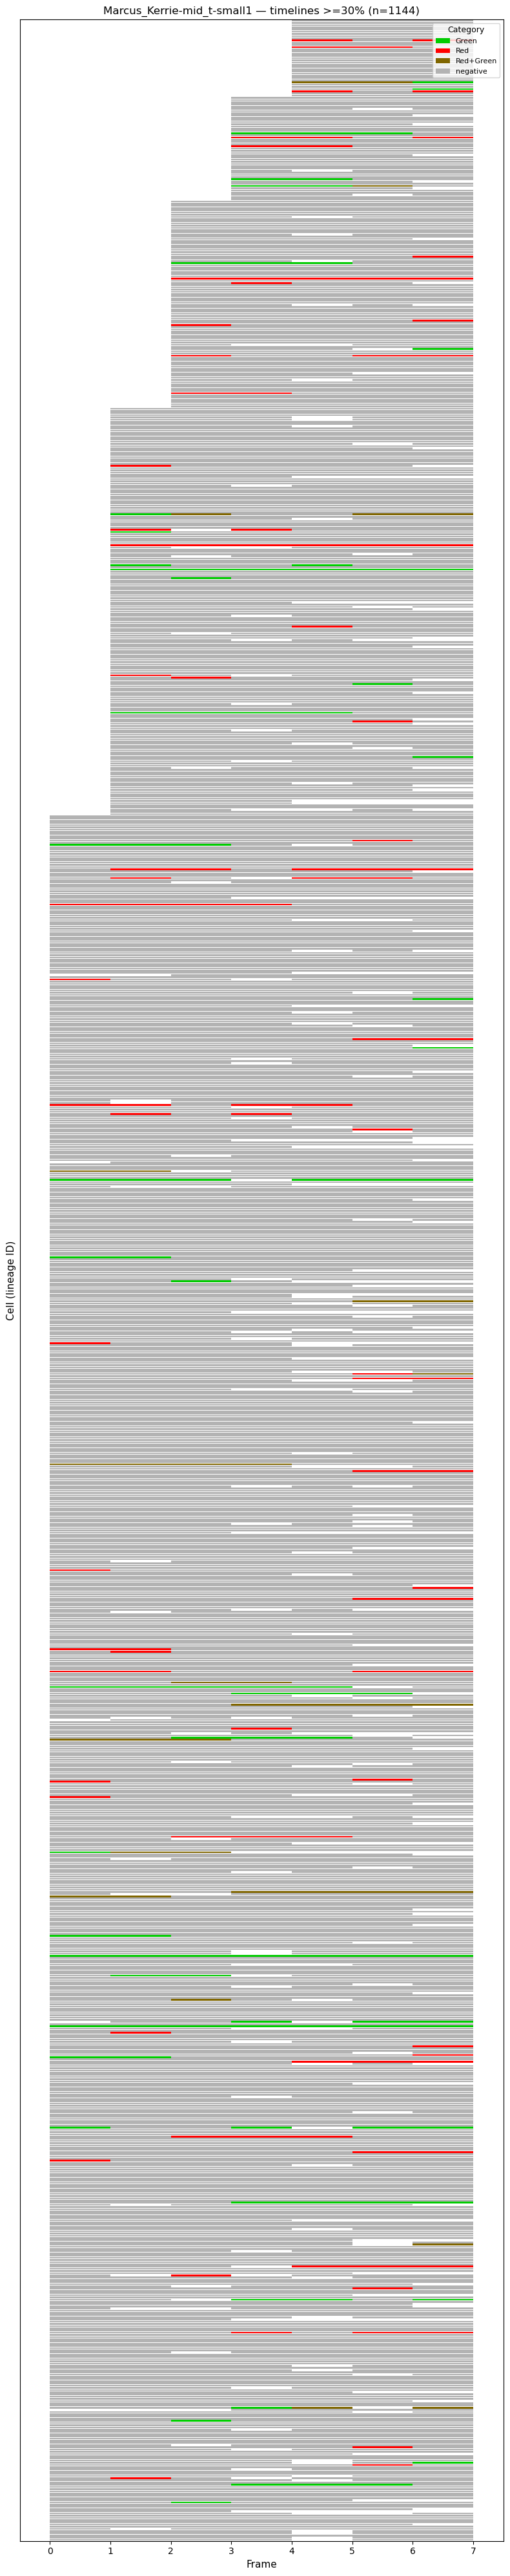

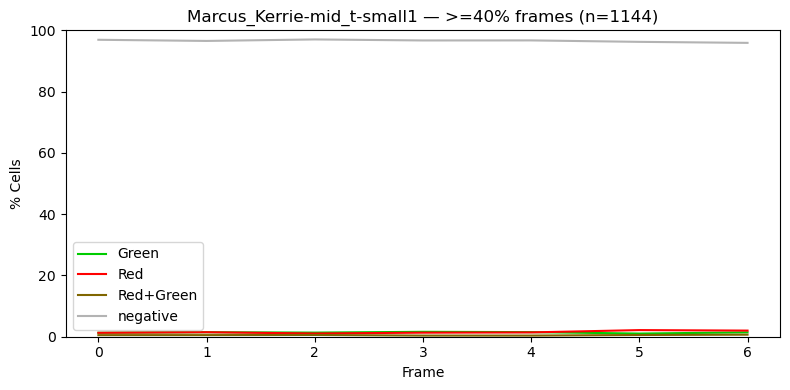

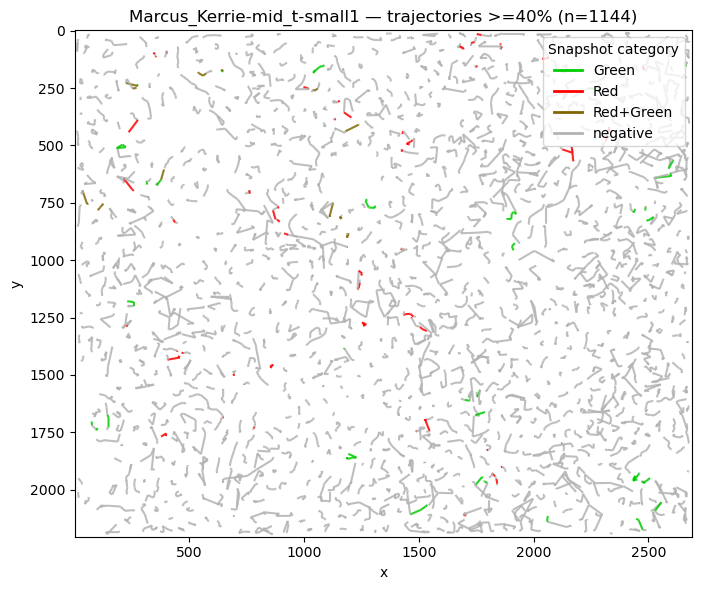

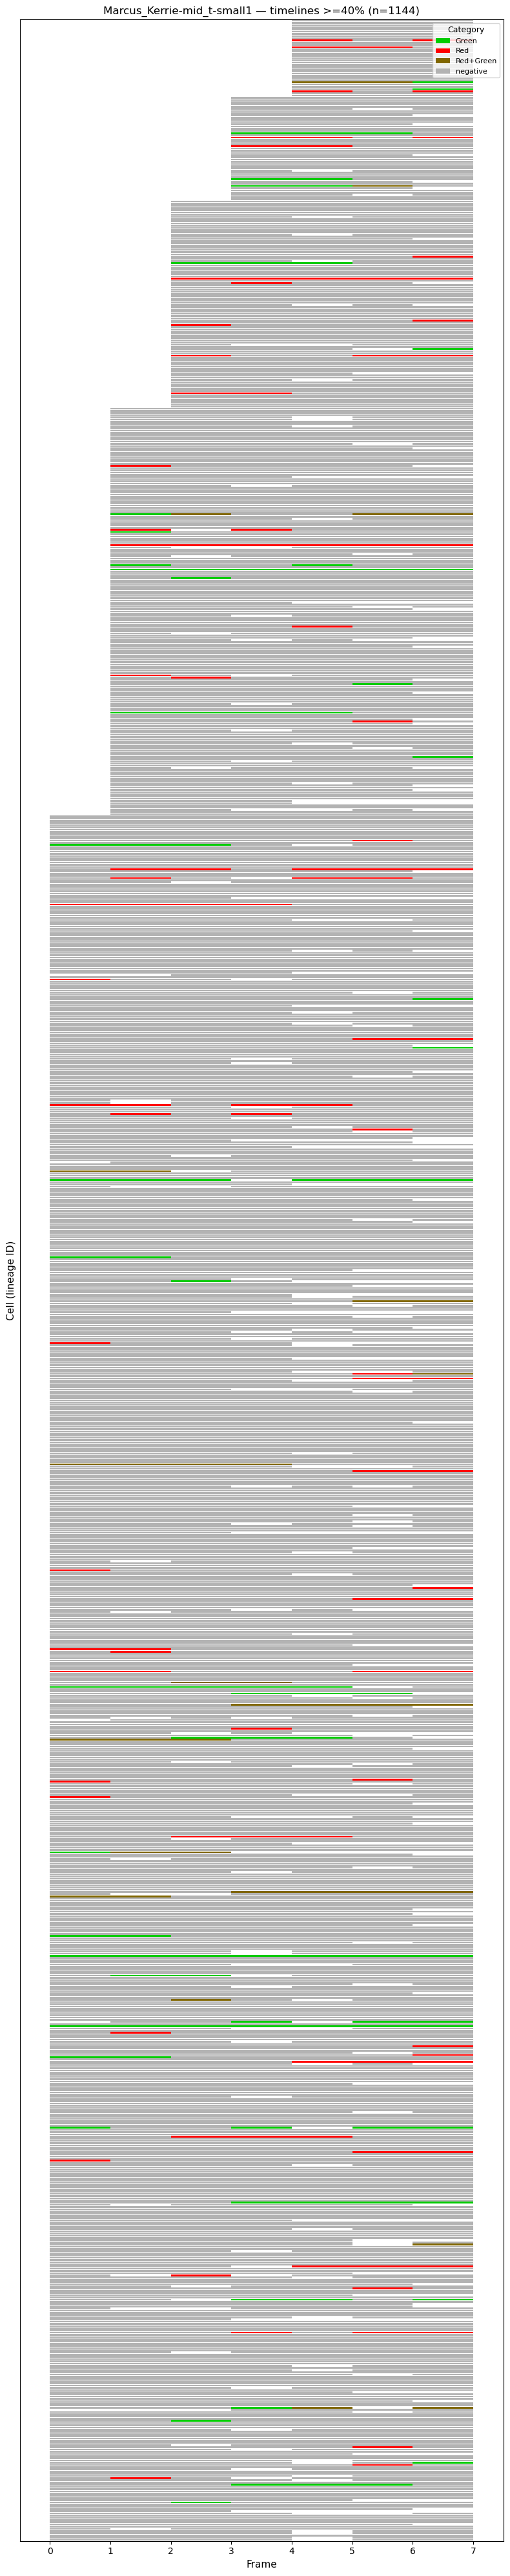

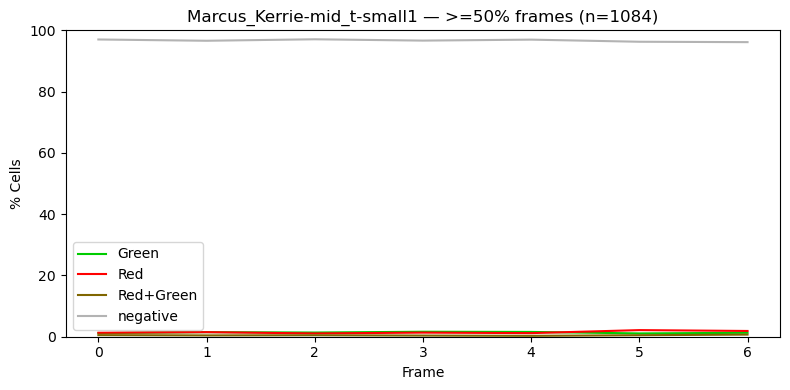

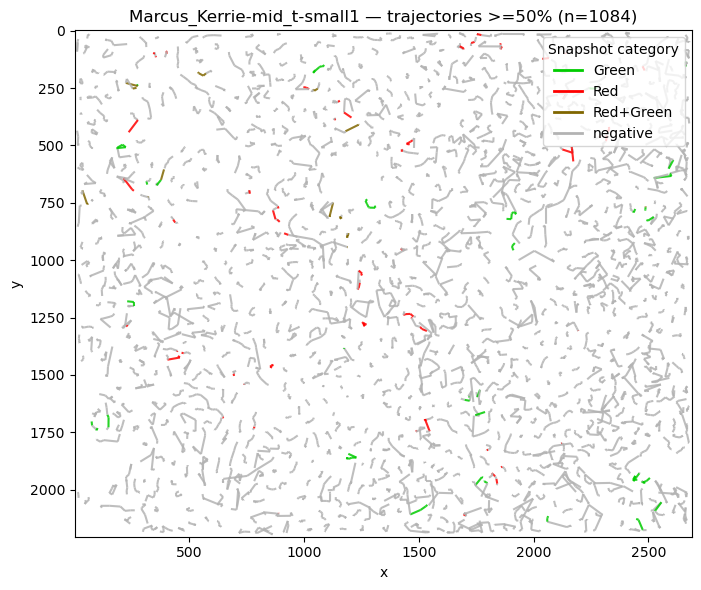

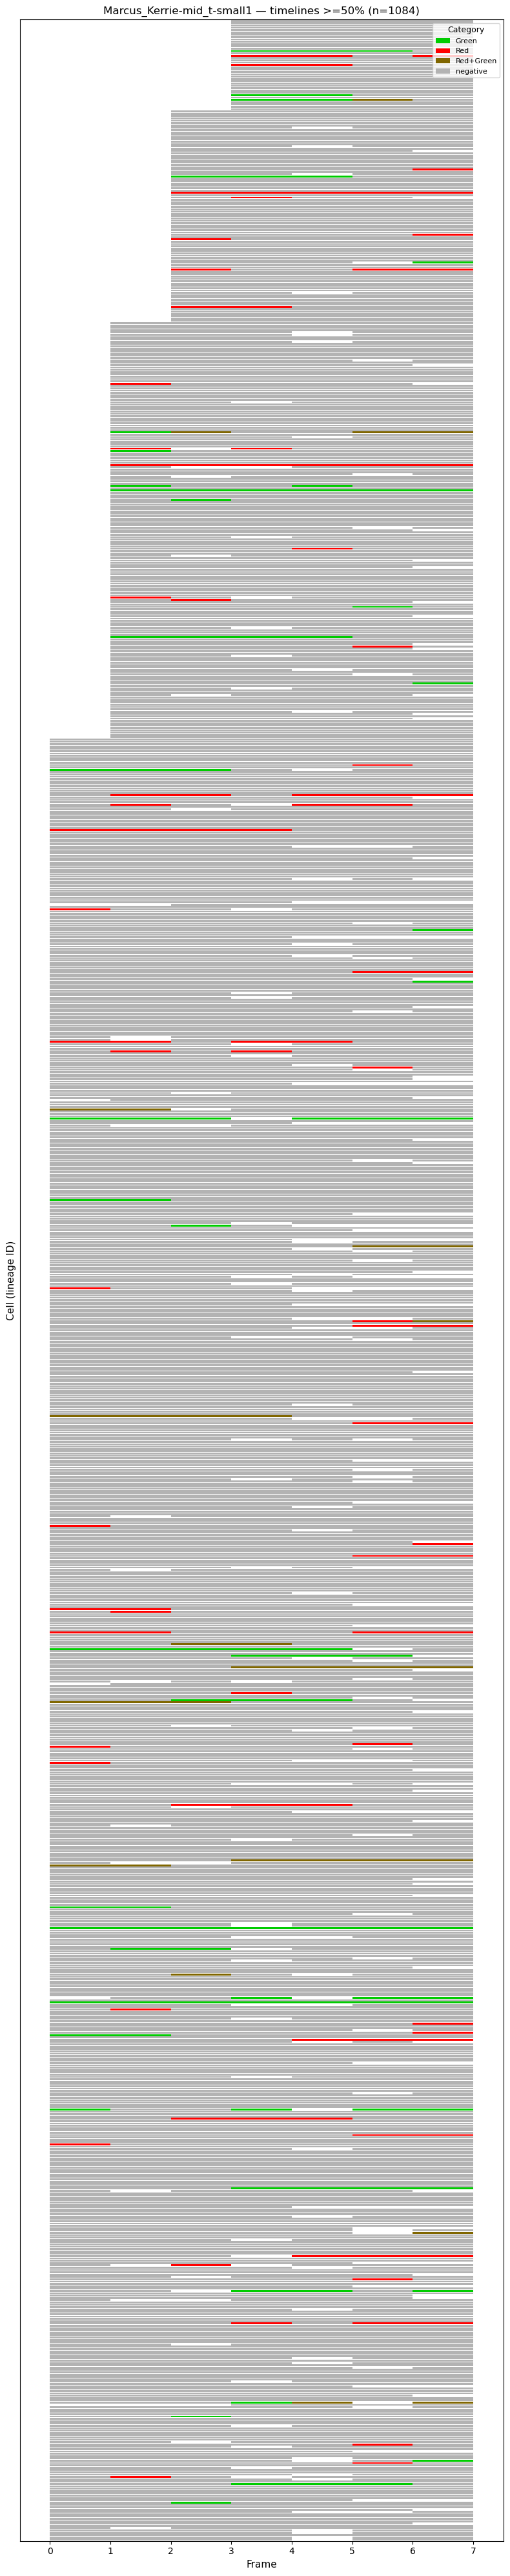

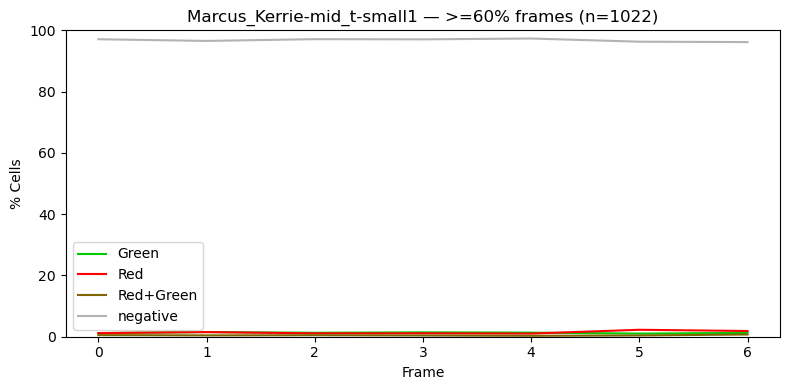

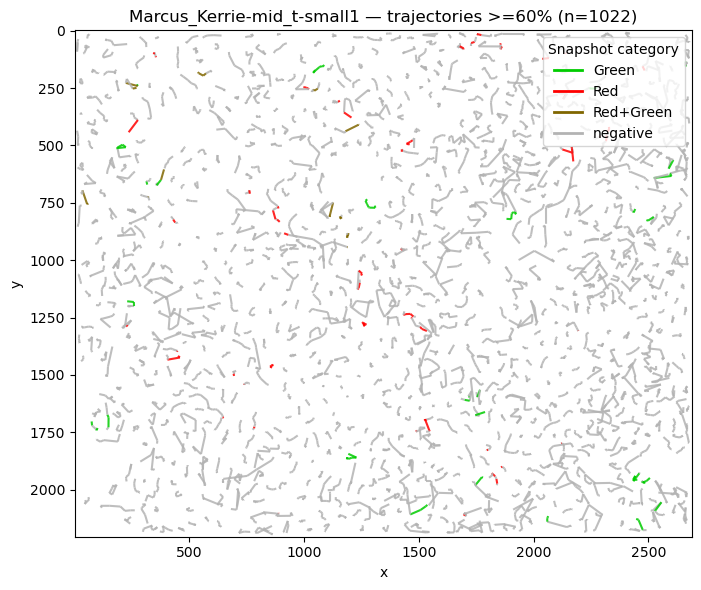

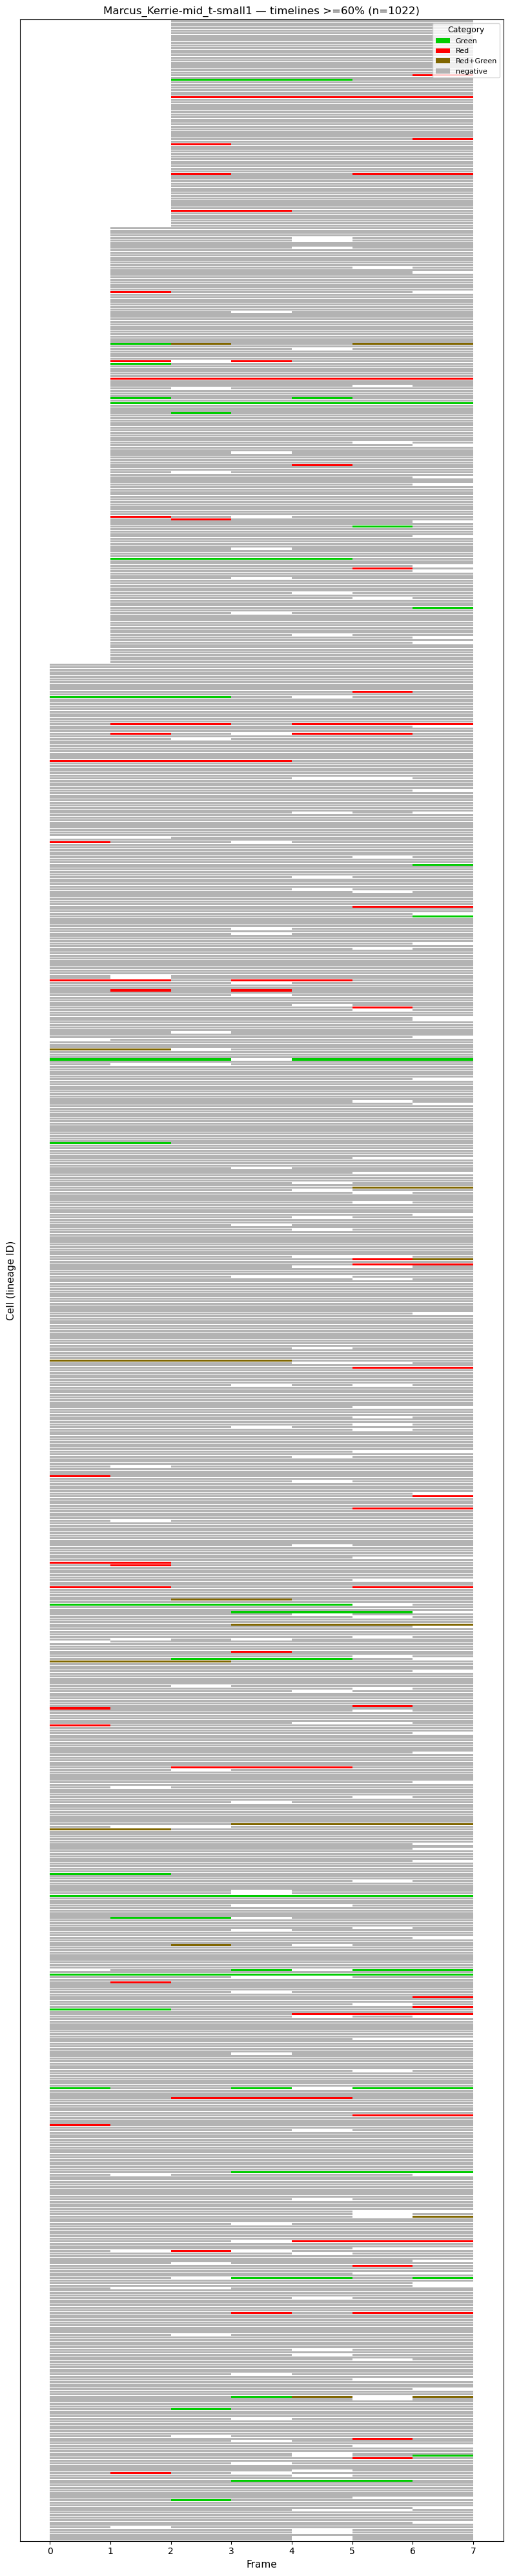

In [ ]:
# Filtered by frame presence — percentages, trajectories, and timelines
for cutoff in cutoff_pcts:
    filtered_tracks, filtered_snapshot = filter_by_frame_presence(tracks_df, snapshot_df, n_frames, cutoff)
    num_cells = filtered_snapshot["label_id"].nunique() if len(filtered_snapshot) > 0 else 0
    if num_cells == 0:
        print(f"No cells at >= {cutoff}% frame presence, skipping")
        continue

    filtered_summary, filtered_categories = compute_snapshot_percentages(filtered_snapshot, n_frames)
    fig, ax = plot_snapshot_percentages(
        filtered_summary, filtered_categories,
        title=f"{tiff_path.stem} — >={cutoff}% frames (n={num_cells})"
    )
    plt.show()

    if len(filtered_tracks) > 0:
        fig, ax = plot_snapshot_trajectories(
            filtered_tracks, filtered_snapshot,
            title=f"{tiff_path.stem} — trajectories >={cutoff}% (n={num_cells})"
        )
        plt.show()

        fig, ax = plot_snapshot_cell_timelines(
            filtered_snapshot, tracks_df=filtered_tracks,
            title=f"{tiff_path.stem} — timelines >={cutoff}% (n={num_cells})"
        )
        plt.show()

In [ ]:
# Build per-category label images from snapshot data
snapshot_category_labels = {}
for category in sorted(snapshot_df["category"].unique()):
    category_stack = np.zeros_like(linked_labels)
    category_rows = snapshot_df[snapshot_df["category"] == category]
    for frame_index, frame_group in category_rows.groupby("frame"):
        cell_ids = frame_group["label_id"].to_numpy(dtype=np.uint32)
        is_in_category = np.isin(linked_labels[frame_index], cell_ids)
        category_stack[frame_index] = np.where(is_in_category, linked_labels[frame_index], 0)
    snapshot_category_labels[category] = category_stack

snapshot_colormap = build_category_colormap(sorted(snapshot_df["category"].unique()))

viewer = napari.Viewer()
viewer.add_labels(linked_labels, name="All cells")
for fluorophore_name in fluorophore_names:
    viewer.add_image(fluor_images[fluorophore_name], name=fluorophore_name, blending="additive")
    viewer.add_labels(positive_cell_labels[fluorophore_name].astype(np.int32),
        name=f"{fluorophore_name} positive (this frame)", opacity=0.4)
for category, category_stack in snapshot_category_labels.items():
    viewer.add_labels(category_stack.astype(np.int32),
        name=f"Snapshot: {category}", opacity=0.5)
napari.run()

---
## 5. Save outputs (optional)

In [38]:
# Uncomment to save CSVs
# assignments_df.to_csv(work_dir / "assignments_persistent.csv", index=False)
# persistent_per_frame.to_csv(work_dir / "persistent_per_frame.csv", index=False)
# snapshot_df.to_csv(work_dir / "snapshot.csv", index=False)
# summary_persistent.to_csv(work_dir / "percentages_persistent.csv", index=False)
# summary_snapshot.to_csv(work_dir / "percentages_snapshot.csv", index=False)